# Exploración de datasets

El presente _notebook_ contiene visualizaciones para los distintos datasets
utilizados en el proyecto, mostrando su correcta carga.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors
import matplotlib.lines as mlines

from matplotlib_map_utils import scale_bar
import partridge as ptg
import quackosm as qosm

import datetime
from pathlib import Path

In [2]:
import xmin
from xmin.dataset import extract_osm_subset

In [3]:
RAW_DATA_PATH = Path("../../data/raw")  # datos no procesados
PRE_DATA_PATH = Path("../../data/processed")  # datos preprocesados
IMG_PATH = Path("../../reports/figures/datasets")
xmin.config.quackosm_working_directory = Path("../../data/interim/quackosm")

In [4]:
OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"

GTFS_PATH = PRE_DATA_PATH / "gtfs"
CENSO_PATH = PRE_DATA_PATH / "censo" / "Cartografia.gpkg"
AMENITY_PATH = PRE_DATA_PATH / "amenities"
OSM_SANTIAGO_PATH = PRE_DATA_PATH / "osm" / "Santiago_tight.osm.pbf"

In [5]:
limites_urbanos_full = gpd.read_file(
    CENSO_PATH,
    layer="Limite_Urbano_CPV24"
)

limites_stgo = limites_urbanos_full[
    (limites_urbanos_full["LOCALIDAD"] == "GRAN SANTIAGO")
]
limites_valpo = limites_urbanos_full[
    (limites_urbanos_full["LOCALIDAD"] == "GRAN VALPARAÍSO")
]
limites_conce = limites_urbanos_full[
    (limites_urbanos_full["LOCALIDAD"] == "GRAN CONCEPCIÓN")
]
limites_pm = limites_urbanos_full[
    (limites_urbanos_full["COMUNA"] == "PUERTO MONTT")
]

In [6]:
if not OSM_SANTIAGO_PATH.exists():
    extract_osm_subset(
        OSM_CHILE_PATH,
        OSM_SANTIAGO_PATH,
        bounds=limites_stgo.union_all()
    )

## H3

In [ ]:
origins_8 = xmin.Origins.create_grid(
    regions=limites_stgo,
    h3_resolution=8
)
len(origins_8.h3_grid)

1286

In [ ]:
origins_9 = xmin.Origins.create_grid(
    regions=limites_stgo,
    h3_resolution=9
)
len(origins_9.h3_grid)

9025

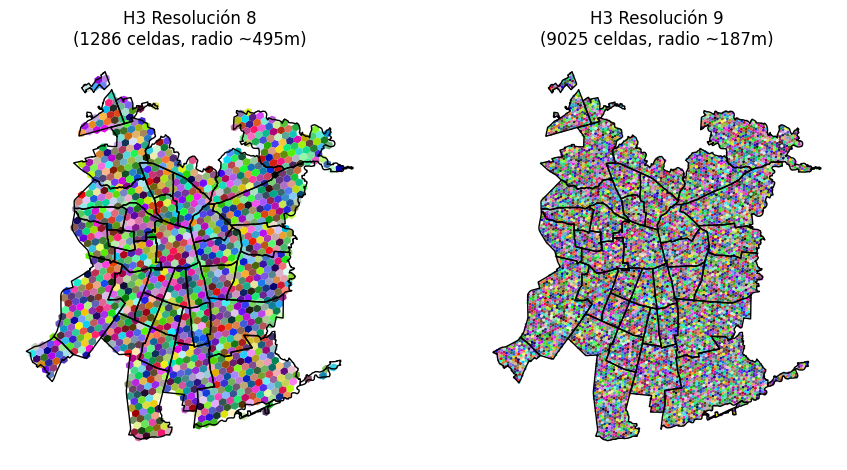

In [ ]:
fig, axs = plt.subplots(1, 2)
fig.set_size_inches(6.4 * 1.5, 4.8)

for ax, hex, level in zip(axs, (origins_8.h3_grid, origins_9.h3_grid), (8, 9)):
    avg_area = hex.to_crs(5361).geometry.area.mean()
    avg_length = np.sqrt(2 * avg_area / (3 * np.sqrt(3)))
    rgb = np.random.random((len(hex), 3))
    hex.plot(ax=ax, color=rgb)
    limites_stgo.plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_axis_off()
    ax.set_title(
        f"H3 Resolución {level}\n({len(hex)} celdas, radio ~{avg_length:.0f}m)"
    )

fig.tight_layout()
plt.savefig(IMG_PATH / "h3.pdf")

## Censo (límites urbanos y población)

### Límites urbanos

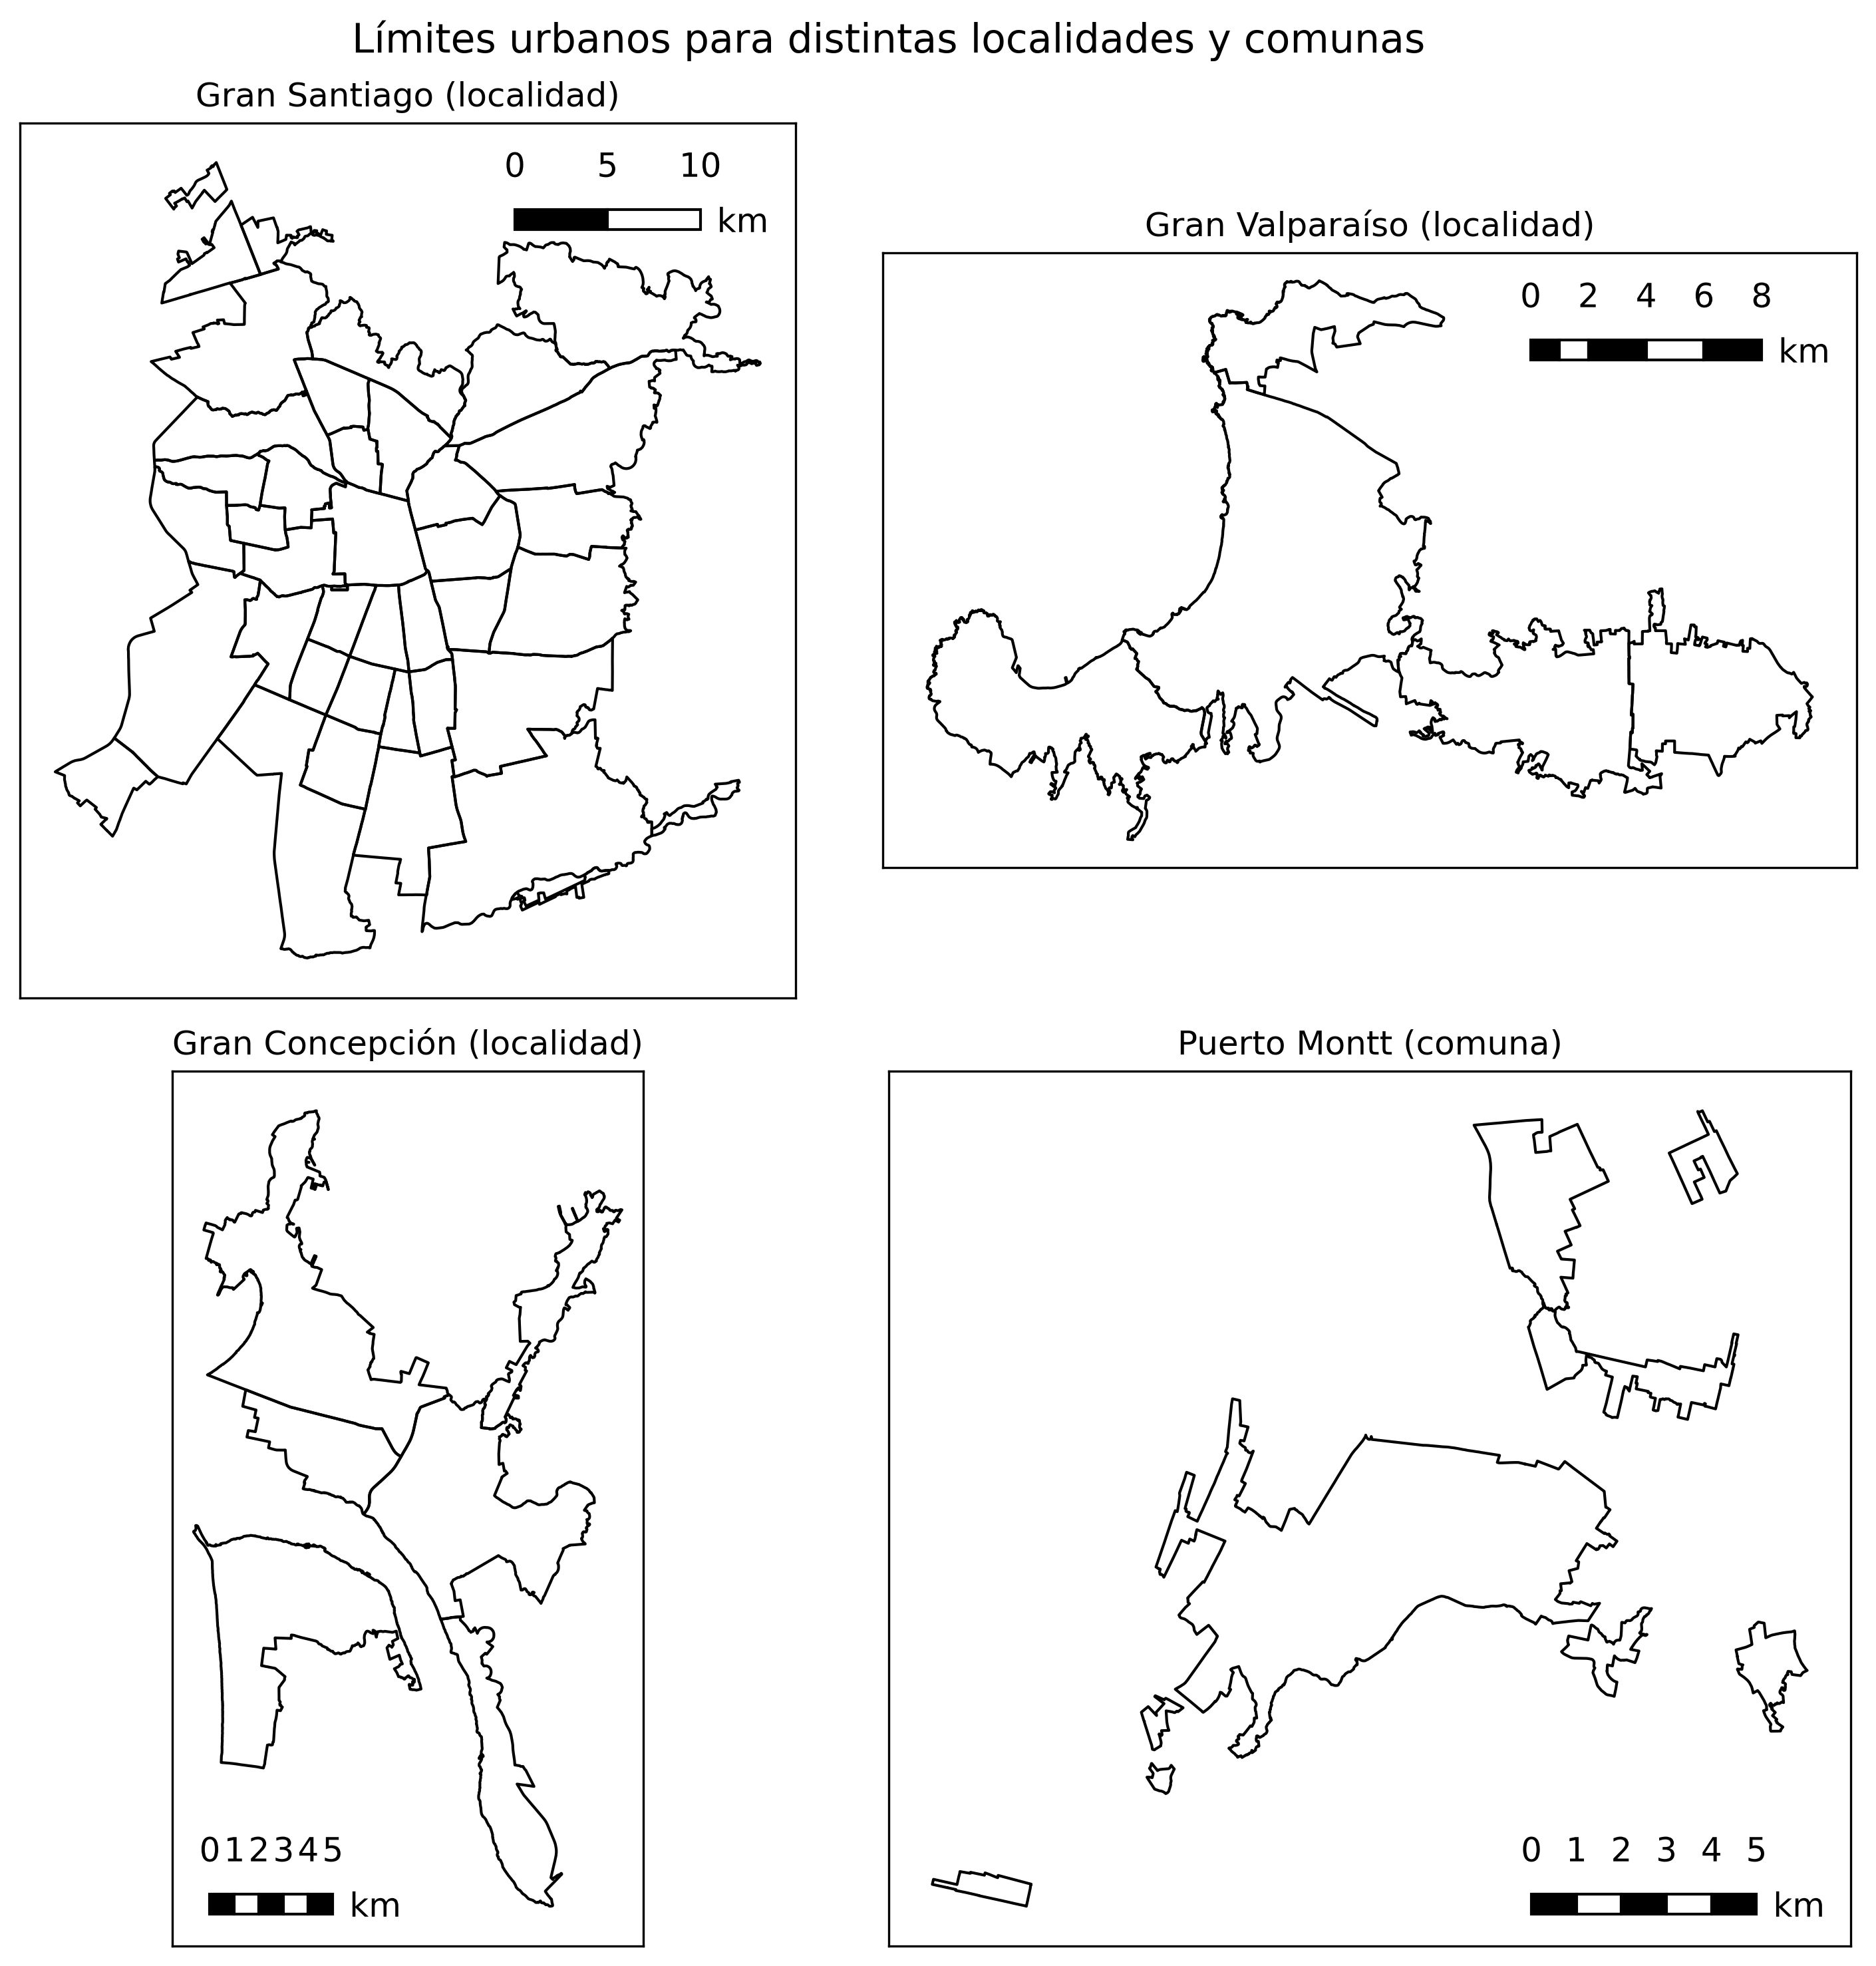

In [ ]:
fig = plt.figure(figsize=(10, 10), dpi=300)
gs = GridSpec(2, 2, figure=fig)
ax_stgo = fig.add_subplot(gs[0, 0])
ax_valpo = fig.add_subplot(gs[0, 1])
ax_conce = fig.add_subplot(gs[1, 0])
ax_pm = fig.add_subplot(gs[1, 1])

for ax, limites, name, scalebar_pos in zip(
    (ax_stgo, ax_valpo, ax_conce, ax_pm),
    (limites_stgo, limites_valpo, limites_conce, limites_pm),
    ("Gran Santiago (localidad)", "Gran Valparaíso (localidad)", "Gran Concepción (localidad)", "Puerto Montt (comuna)"),
    ("upper right", "upper right", "lower left", "lower right"),
):
    limites.to_crs(xmin.config.projected_crs).plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_xticks([])
    ax.set_yticks([])
    scale_bar(ax=ax, location=scalebar_pos, bar={"unit": "km", "projection": xmin.config.projected_crs})
    ax.set_title(name)

fig.suptitle(
    "Límites urbanos para distintas localidades y comunas",
    fontsize="x-large",
)

plt.tight_layout()
plt.savefig(IMG_PATH / "limites_urbanos.pdf")

### Población

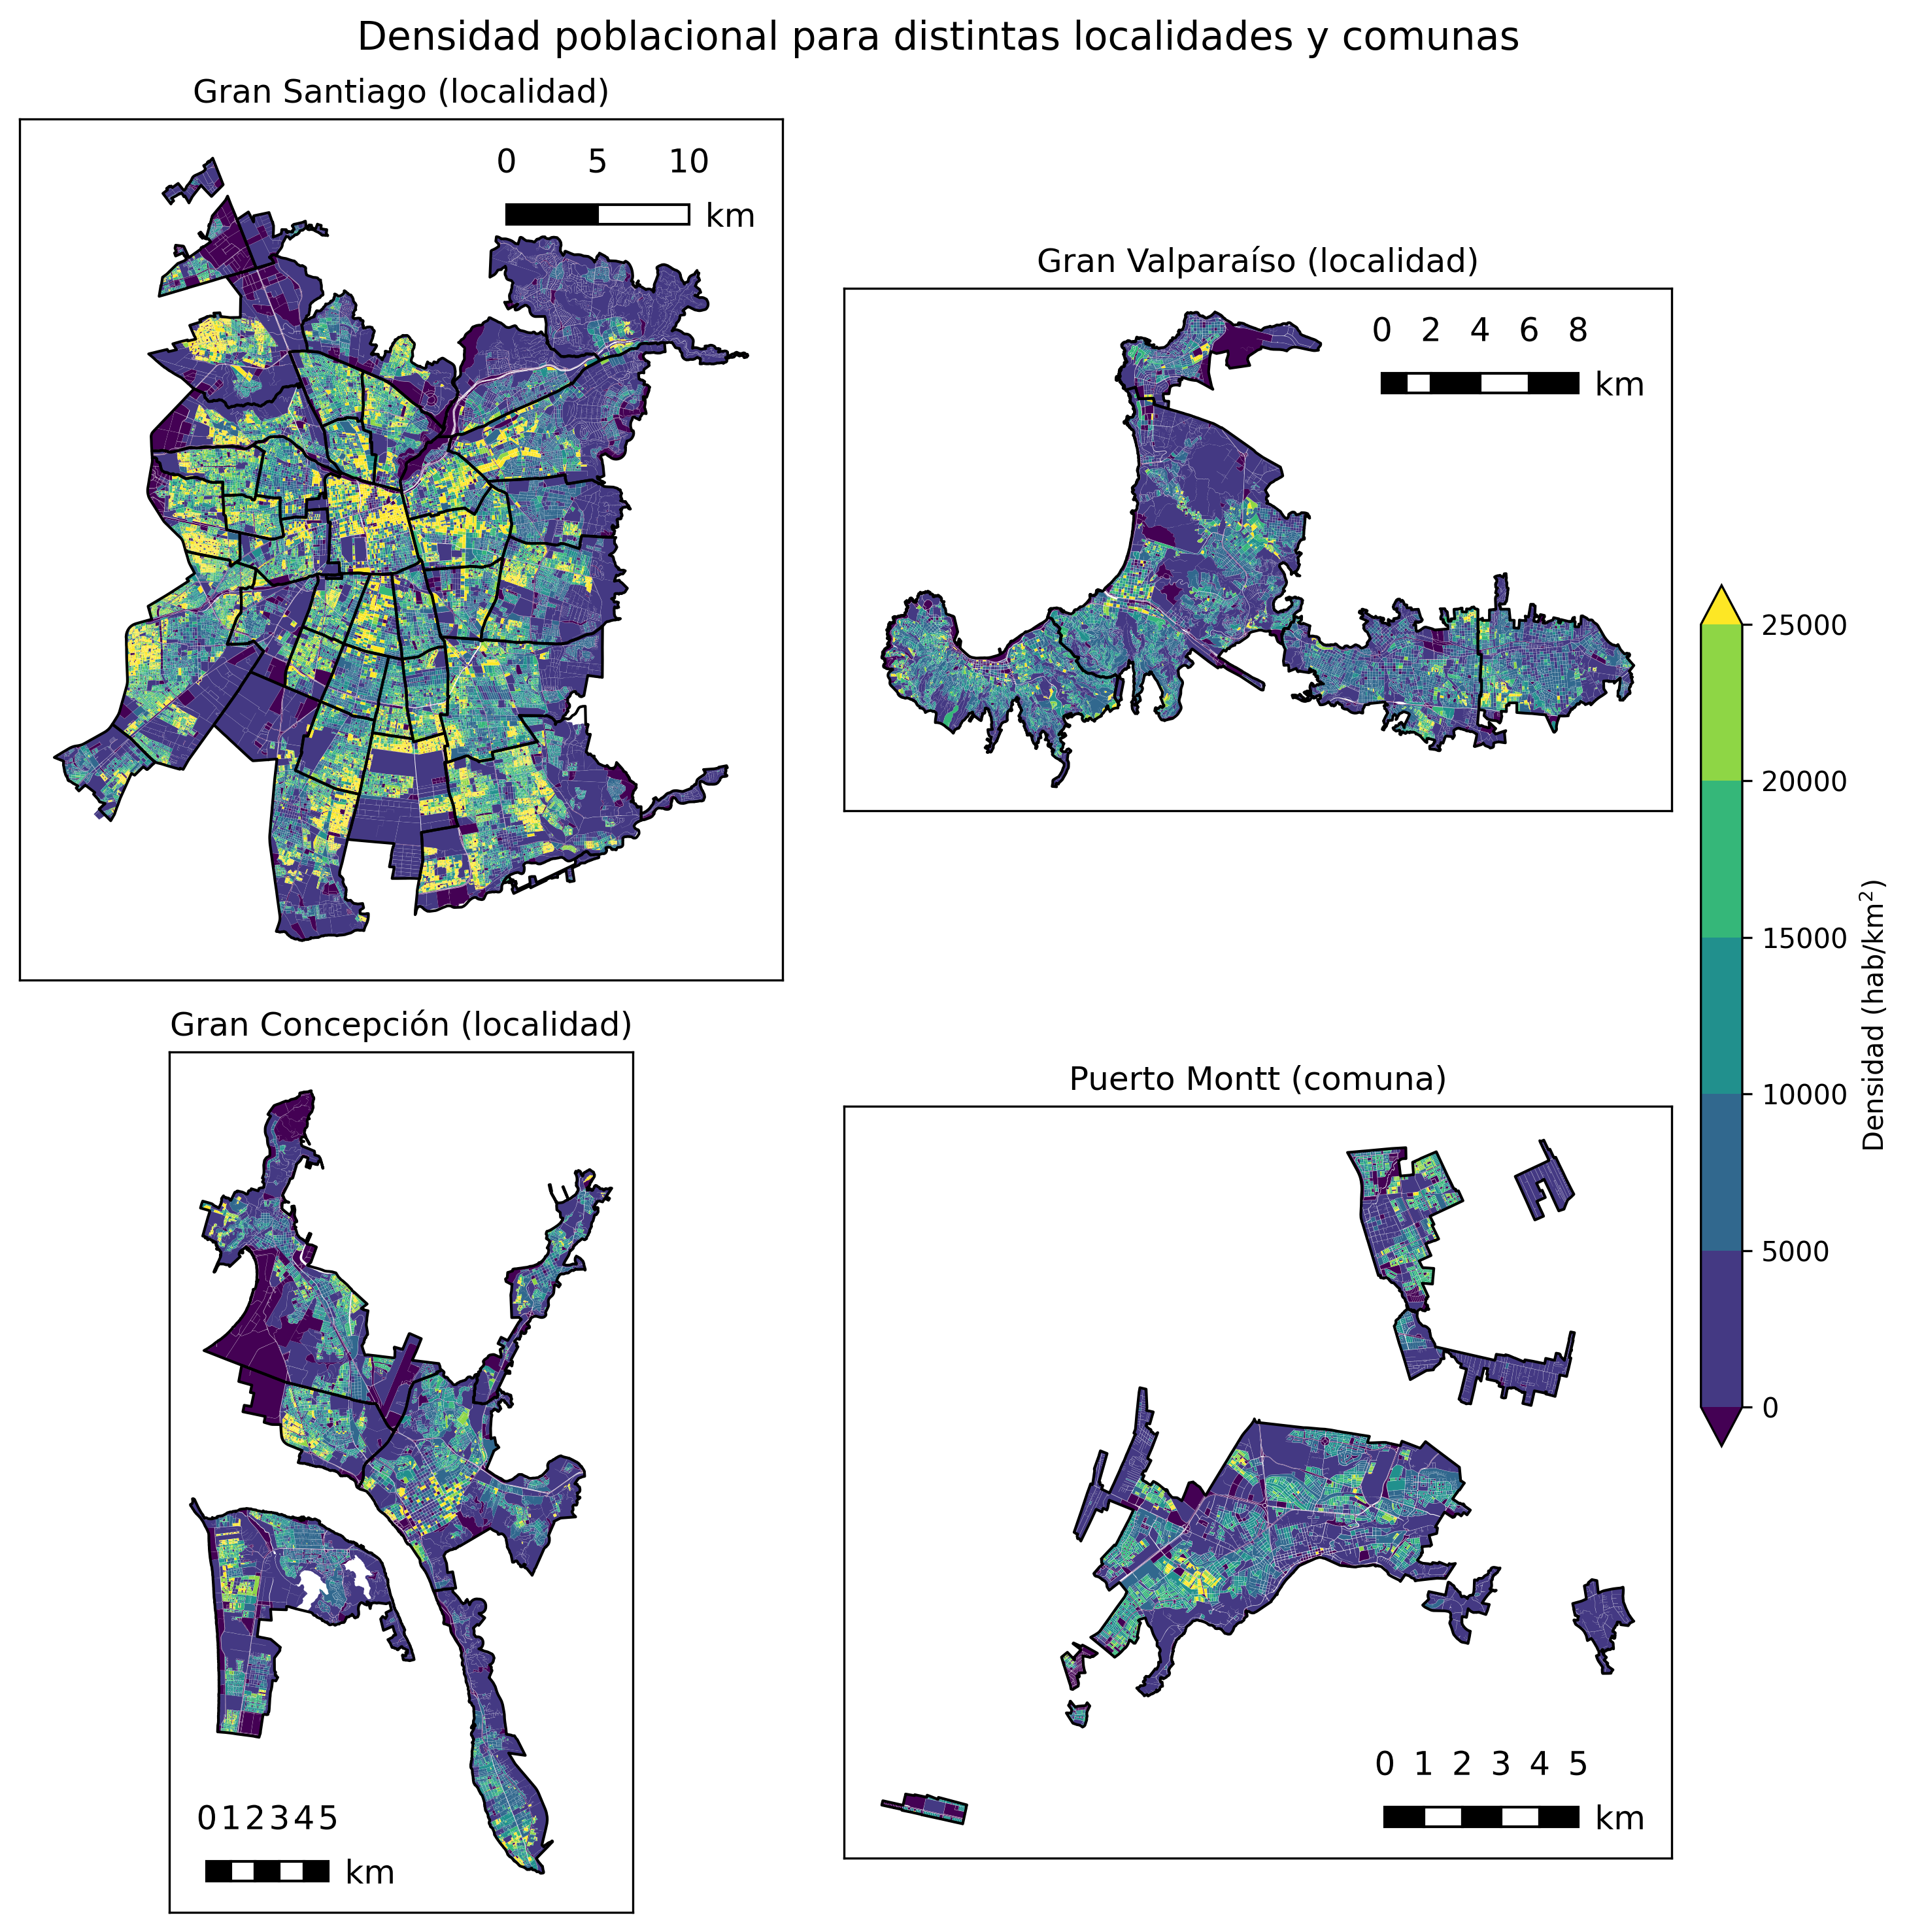

In [ ]:
fig = plt.figure(figsize=(10, 10), dpi=300)
gs = GridSpec(4, 3, figure=fig, width_ratios=[100, 100, 5])
ax_stgo = fig.add_subplot(gs[0:2, 0])
ax_valpo = fig.add_subplot(gs[0:2, 1])
ax_conce = fig.add_subplot(gs[2:4, 0])
ax_pm = fig.add_subplot(gs[2:4, 1])
ax_cb = fig.add_subplot(gs[1:3, 2])

norm = mcolors.BoundaryNorm(
    [1e-10, 5_000, 10_000, 15_000, 20_000, 25_000], ncolors=256, extend="both"
)

for ax, limites, name, scalebar_pos in zip(
    (ax_stgo, ax_valpo, ax_conce, ax_pm),
    (limites_stgo, limites_valpo, limites_conce, limites_pm),
    (
        "Gran Santiago (localidad)",
        "Gran Valparaíso (localidad)",
        "Gran Concepción (localidad)",
        "Puerto Montt (comuna)",
    ),
    ("upper right", "upper right", "lower left", "lower right"),
):
    manzanas = gpd.read_file(
        CENSO_PATH,
        layer="Manzanas_CPV24",
        use_arrow=True,
        mask=limites.union_all()
    ).to_crs(xmin.config.projected_crs)
    manzanas["density"] = manzanas["n_per"] / manzanas.area * 1_000_000
    manzanas.plot("density", ax=ax, edgecolor="none", norm=norm)
    limites.to_crs(xmin.config.projected_crs).plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_xticks([])
    ax.set_yticks([])
    scale_bar(
        ax=ax,
        location=scalebar_pos,
        bar={"unit": "km", "projection": xmin.config.projected_crs},
    )
    ax.set_title(name)

cbar = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
axCbar = fig.colorbar(cbar, cax=ax_cb)
axCbar.set_label(f"Densidad (hab/km$^2$)")

fig.suptitle(
    "Densidad poblacional por manzana para distintas localidades y comunas",
    fontsize="x-large",
)

plt.tight_layout()
plt.savefig(IMG_PATH / "poblacion.pdf")

## GTFS

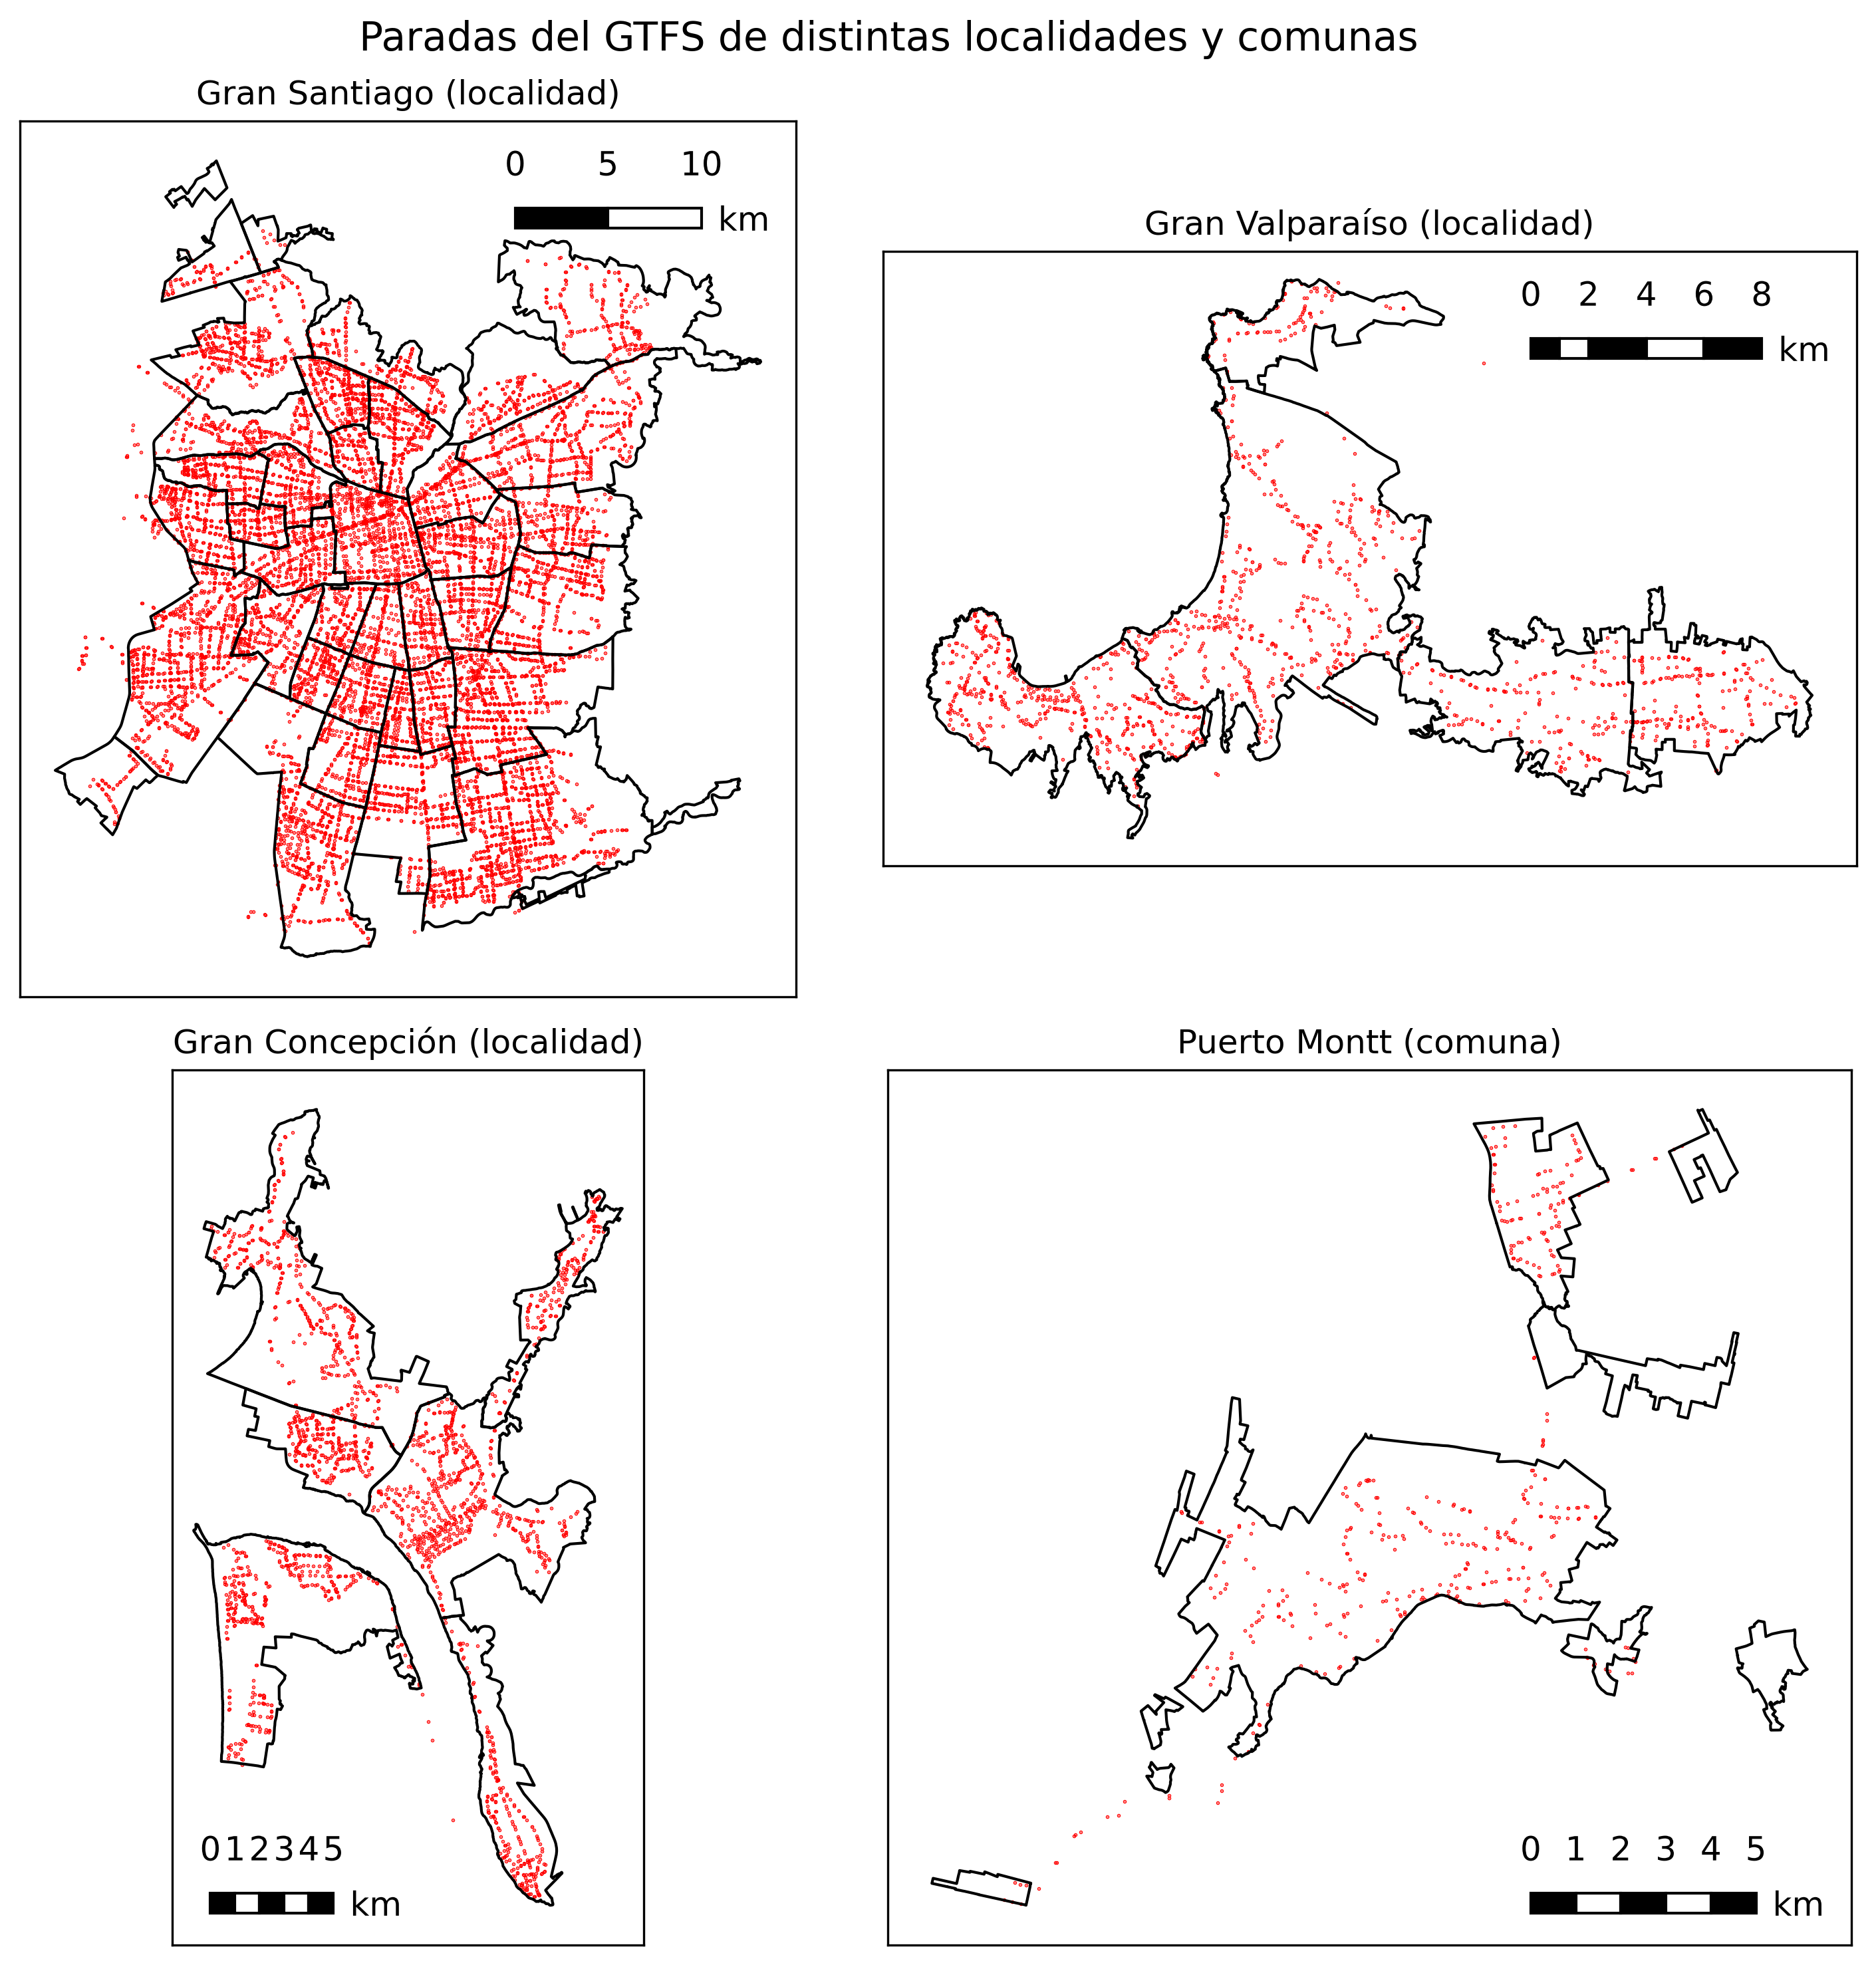

In [21]:
fig = plt.figure(figsize=(10, 10), dpi=300)
gs = GridSpec(2, 2, figure=fig)
ax_stgo = fig.add_subplot(gs[0, 0])
ax_valpo = fig.add_subplot(gs[0, 1])
ax_conce = fig.add_subplot(gs[1, 0])
ax_pm = fig.add_subplot(gs[1, 1])

for ax, limites, name, gtfs_zip, scalebar_pos in zip(
    (ax_stgo, ax_valpo, ax_conce, ax_pm),
    (limites_stgo, limites_valpo, limites_conce, limites_pm),
    (
        "Gran Santiago (localidad)",
        "Gran Valparaíso (localidad)",
        "Gran Concepción (localidad)",
        "Puerto Montt (comuna)",
    ),
    ("Santiago.zip", "Valparaiso.zip", "Concepcion.zip", "Puerto_Montt.zip"),
    ("upper right", "upper right", "lower left", "lower right"),
):
    limites = limites.to_crs(xmin.config.projected_crs)
    feed = ptg.load_raw_feed(GTFS_PATH / gtfs_zip)
    stops_series = gpd.GeoSeries(
        gpd.points_from_xy(
            pd.to_numeric(feed.stops["stop_lon"]),
            pd.to_numeric(feed.stops["stop_lat"]),
        ),
        crs=4326,
    ).to_crs(xmin.config.projected_crs)
    stops_series[stops_series.within(limites.union_all().convex_hull)].plot(
        ax=ax, markersize=0.1, facecolor="red"
    )
    limites.plot(ax=ax, facecolor="none", edgecolor="black")
    ax.set_xticks([])
    ax.set_yticks([])
    scale_bar(
        ax=ax,
        location=scalebar_pos,
        bar={"unit": "km", "projection": xmin.config.projected_crs},
    )
    ax.set_title(name)

fig.suptitle(
    "Paradas del GTFS de distintas localidades y comunas",
    fontsize="x-large",
)

plt.tight_layout()
plt.savefig(IMG_PATH / "gtfs.pdf")

## OpenStreetMap

In [ ]:
supermercados = xmin.Amenity.from_osm(
    name="supermercados",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"shop": ["supermarket"]},
    keep_all_tags=["name"]
)

bancos = xmin.Amenity.from_osm(
    name="bancos",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"amenity": ["bank"]},
    keep_all_tags=["name"]
)

bibliotecas = xmin.Amenity.from_osm(
    name="bibliotecas",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"amenity": ["library"]},
    keep_all_tags=["name"]
)

In [21]:
roads_gdf = qosm.convert_pbf_to_geodataframe(
    pbf_path=OSM_SANTIAGO_PATH,
    tags_filter={"highway": True},
    working_directory=xmin.config.quackosm_working_directory,
    geometry_filter=limites_stgo.union_all(),
)
roads_gdf = roads_gdf[
    (roads_gdf.geom_type != "Point")
    & ~(
        roads_gdf["highway"].isin(
            [
                "cycleway",
                "motor",
                "proposed",
                "construction",
                "abandoned",
                "platform",
                "raceway",
                "motorway",
                "motorway_link",
            ]
        )
    )
]

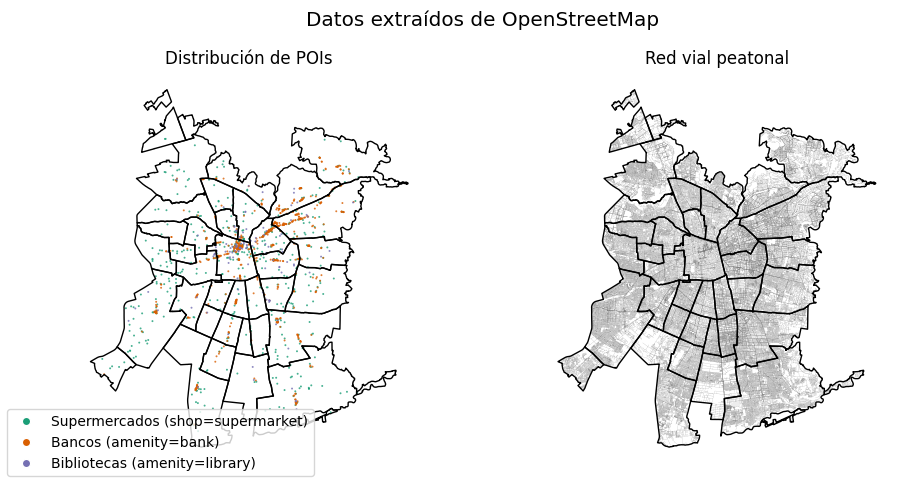

In [28]:
fig, (ax_pois, ax_net) = plt.subplots(1, 2)
fig.set_size_inches(6.4*1.5, 4.8)

limites_stgo.plot(ax=ax_pois, facecolor="none", edgecolor="black", zorder=2)
supermercados.amenity_gdf.plot(ax=ax_pois, edgecolor="none", facecolor="#1b9e77", alpha=0.8, markersize=2)
bancos.amenity_gdf.plot(ax=ax_pois, edgecolor="none", facecolor="#d95f02", alpha=0.8, markersize=2)
bibliotecas.amenity_gdf.plot(ax=ax_pois, edgecolor="none", facecolor="#7570b3", alpha=0.8, markersize=2)
ax_pois.set_axis_off()
ax_pois.set_title("Distribución de POIs")

handles = [
    mlines.Line2D([], [], color="white", marker='o', markerfacecolor="#1b9e77"),
    mlines.Line2D([], [], color="white", marker='o', markerfacecolor="#d95f02"),
    mlines.Line2D([], [], color="white", marker='o', markerfacecolor="#7570b3"),
]
labels = [
    "Supermercados (shop=supermarket)",
    "Bancos (amenity=bank)",
    "Bibliotecas (amenity=library)",
]
fig.legend(handles, labels, loc="lower left")

roads_gdf.plot(ax=ax_net, linewidth=0.1, edgecolor="grey", facecolor="none")
limites_stgo.plot(ax=ax_net, facecolor="none", edgecolor="black", zorder=10)
ax_net.set_axis_off()
ax_net.set_title("Red vial peatonal")

fig.suptitle("Datos extraídos de OpenStreetMap", fontsize="x-large")
fig.tight_layout()
plt.savefig(IMG_PATH / "osm.pdf")

## Farmacias

In [ ]:
def get_short_name(name: str | float) -> str:
    """
    Recibe el nombre de una farmacia. Si es NaN, retorna NaN. Si no, retorna la
    última palabra del nombre (descartando "farmacia" o "farmacias"), en
    minúscula y sin acentos.
    """
    
    return (
        name
        if type(name) != str
        else name.lower()
        .translate(str.maketrans("áéíóúüñ", "AEIOUUN"))
        .replace("farmacias", "")
        .replace("farmacia", "")
        .strip()
        .split(" ")[-1]
    )

In [29]:
farmacias_osm = (
    xmin.Amenity.from_osm(
        name="farmacias",
        osm_path=OSM_SANTIAGO_PATH,
        osm_filter={"amenity": ["pharmacy"]},
        keep_all_tags=["name"],
    )
    .amenity_gdf.to_crs(xmin.config.projected_crs)
)
farmacias_osm["short_name"] = farmacias_osm["name"].apply(get_short_name)

In [30]:
farmacias_minsal = gpd.read_file(
    AMENITY_PATH / "farmacias.gpkg", mask=limites_stgo.union_all()
).to_crs(xmin.config.projected_crs)[["id", "name", "geometry"]]
farmacias_minsal["short_name"] = farmacias_minsal["name"].apply(get_short_name)

In [33]:
farmacias_joined = farmacias_minsal.sjoin(
    farmacias_osm,
    how="inner",
    predicate="dwithin",
    distance=100,
    on_attribute=["short_name"],
    lsuffix="minsal",
    rsuffix="osm",
)

In [37]:
farmacias_only_osm = farmacias_osm[~farmacias_osm["id"].isin(farmacias_joined["id_osm"])].to_crs(4326)
farmacias_only_minsal = farmacias_minsal[~farmacias_minsal["id"].isin(farmacias_joined["id_minsal"])].to_crs(4326)
farmacias_common = farmacias_minsal[farmacias_minsal["id"].isin(farmacias_joined["id_minsal"])].to_crs(4326)

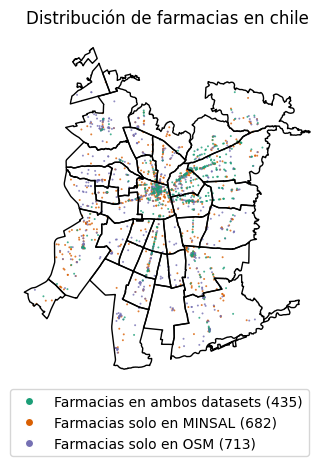

In [48]:
fig, ax = plt.subplots()

limites_stgo.plot(ax=ax, facecolor="none", edgecolor="black", zorder=2)
farmacias_common.plot(ax=ax, edgecolor="none", facecolor="#1b9e77", alpha=0.8, markersize=2, zorder=1.5)
farmacias_only_minsal.plot(ax=ax, edgecolor="none", facecolor="#d95f02", alpha=0.8, markersize=2)
farmacias_only_osm.plot(ax=ax, edgecolor="none", facecolor="#7570b3", alpha=0.8, markersize=2)
ax.set_axis_off()
ax.set_title("Distribución de farmacias en chile")

handles = [
    mlines.Line2D([], [], color="white", marker='o', markerfacecolor="#1b9e77"),
    mlines.Line2D([], [], color="white", marker='o', markerfacecolor="#d95f02"),
    mlines.Line2D([], [], color="white", marker='o', markerfacecolor="#7570b3"),
]
labels = [
    f"Farmacias en ambos datasets ({len(farmacias_common)})",
    f"Farmacias solo en MINSAL ({len(farmacias_only_minsal)})",
    f"Farmacias solo en OSM ({len(farmacias_only_osm)})",
]
ax.legend(handles, labels, loc=(0, -0.2))

plt.tight_layout()
plt.savefig(IMG_PATH / "farmacias.pdf")